### Outliers with z-score + visualization

In [22]:
import numpy as np
import pandas as pd
from scipy import stats

# load dataset
df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")

# target variable
variable = "Rating"
z_scores = stats.zscore(df[variable])

# Define a threshold for outliers
# modify this as needed, default is 3 (based on normal distribution)
# try this with 2 or 2.5, and then see how much data we lose 
# even if the distribution is closer to normal distribution now
threshold = 2

# Detect outliers
outliers = df[np.abs(z_scores) > threshold]

print("Detected outliers using Z-score:")
outliers

Detected outliers using Z-score:


,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill


**This version of the visualization shows the dataset from 1st to last house in original order.**

We can see how scattered the outlier houses are based on price this way.

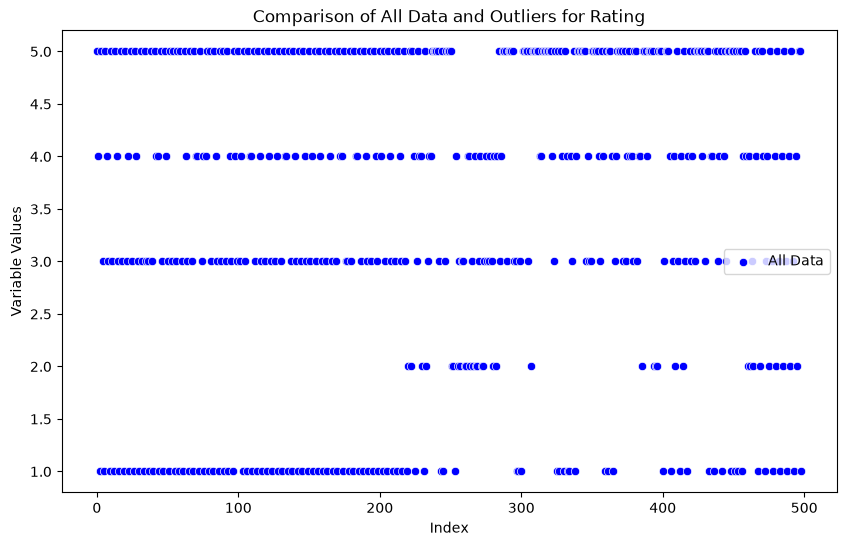

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot setup
plt.figure(figsize=(10, 6))

# which variable we are visualizing, usually a variable 
# we detected the outliers from or target variable
variable = "Rating"

# NOTE! outliers is the dataframe that contains only the outliers or noise items

# Plot the full dataset (in blue, for example)
sns.scatterplot(x=df.index, y=df[variable], color='blue', label='All Data')

# Overlay the outliers (in red)
sns.scatterplot(x=outliers.index, y=outliers[variable], color='red', label='Outliers/Noise')

# Add title and labels
plt.title(f'Comparison of All Data and Outliers for {variable}')
plt.xlabel('Index')
plt.ylabel('Variable Values')

# Show legend
plt.legend()

# Display the plot
plt.show()

<Axes: >

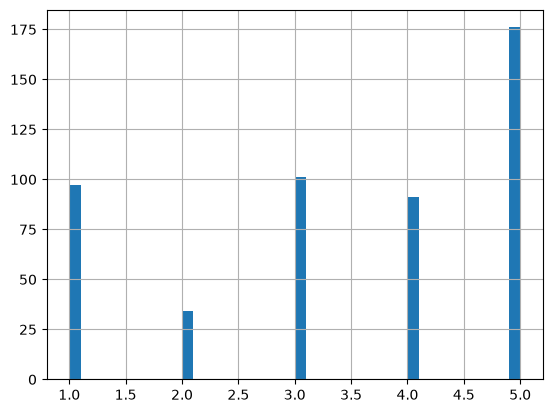

In [24]:
# take the original dataframe MINUS the outliers
inliers = df[~df.index.isin(outliers.index)]


inliers['Rating'].hist(bins=40)

In [25]:
import numpy as np
import pandas as pd

df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")

variable = "Rating"

# Calculate Q1, Q3, and IQR
Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Add outlier column: 1 = outlier, 0 = not an outlier
df["outlier"] = (
    (df[variable] < lower_bound) |
    (df[variable] > upper_bound)
).astype(int)

print(df["outlier"].value_counts())

outlier
0    499
Name: count, dtype: int64


### EXTRA - pairplot for all variables (outliers)

This can be slow to generate, uncomment the code if you wish to try it.

In [26]:
# # Visualize
# import seaborn as sns

# sns.pairplot(
#     df,
#     vars=df.columns.drop("outlier"),
#     hue="outlier",
#     diag_kind="hist",
#     plot_kws={"alpha": 0.5}
# )

# plt.show()